In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [2]:
# ------------------------------------DATA_CLEANING--------------------------
def preprocess(data):
    from sklearn.preprocessing import LabelEncoder
    data = data.drop('customerID',axis=1)
    data['gender'] = data['gender'].map({'Female':0,'Male':1})
    data['Partner'] = data['Partner'].map({'Yes':1,'No':0})
    data['Dependents'] = data['Dependents'].map({'Yes':1,'No':0})
    data['PhoneService'] = data['PhoneService'].map({'Yes':1,'No':0})
    data['MultipleLines'] = data['MultipleLines'].map({'Yes':1,'No':-1,'No phone service':0})
    data['InternetService'] = data['InternetService'].map({'DSL':1,'No':-1,'Fiber optic':0})
    data['OnlineSecurity'] = data['OnlineSecurity'].map({'Yes':1,'No':-1,'No internet service':0})
    data['DeviceProtection'] = data['DeviceProtection'].map({'Yes':1,'No':-1,'No internet service':0})
    data['OnlineBackup'] = data['OnlineBackup'].map({'Yes':1,'No':-1,'No internet service':0})
    data['TechSupport'] = data['TechSupport'].map({'Yes':1,'No':-1,'No internet service':0})
    data['StreamingTV'] = data['StreamingTV'].map({'Yes':1,'No':-1,'No internet service':0})
    data['StreamingMovies'] = data['StreamingMovies'].map({'Yes':1,'No':-1,'No internet service':0})
    data['Contract'] = data['Contract'].map({'Two year':2,'One year':1,'Month-to-month':0})
    data['PaperlessBilling'] = data['PaperlessBilling'].map({'Yes':1,'No':0})
    le = LabelEncoder()
    data['PaymentMethod'] = le.fit_transform(data['PaymentMethod'])
    data['TotalCharges'] = data['TotalCharges'].replace(' ',0.0)
    data['TotalCharges'] = data['TotalCharges'].astype('float64')
    data['Churn'] = data['Churn'].map({'Yes':1,'No':0})
    return data
import pandas as pd
data = pd.read_csv('new_data.csv')
data = preprocess(data)
# print(data.info())

Text(0.5, 1.0, 'Correlation Heatmap')

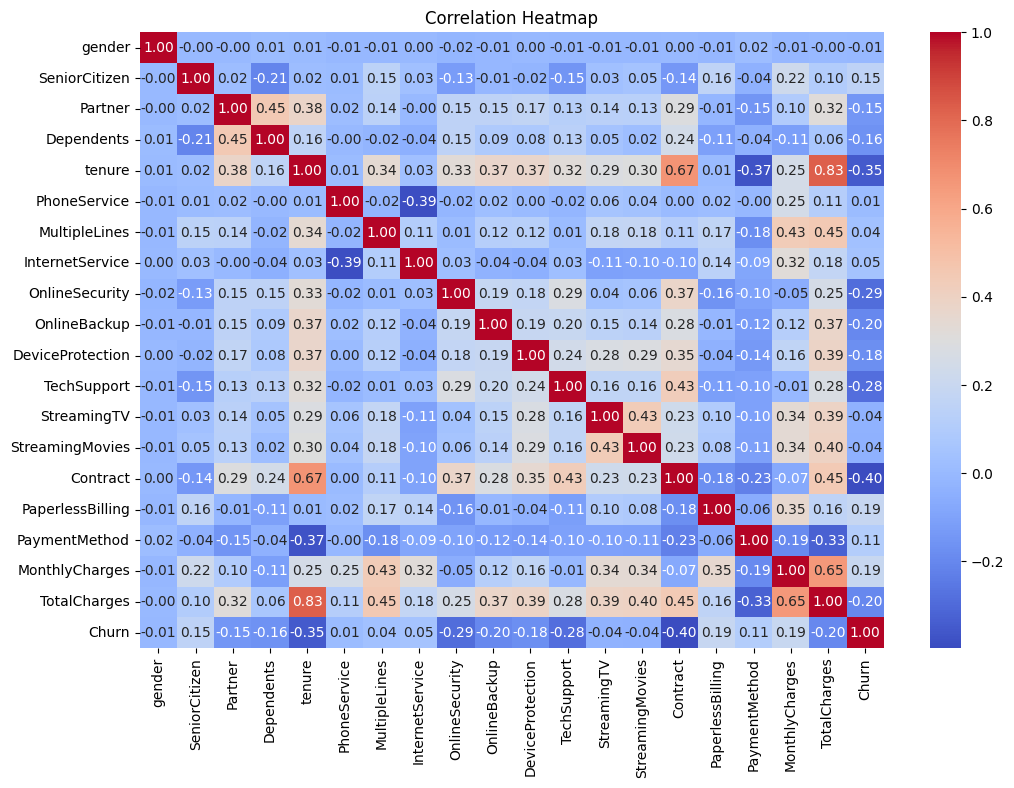

In [3]:
# -------------------------Correlation_diagnosis-----------------
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
# plt.show()


In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select numeric features only
X = data

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)


             feature        VIF
0             gender   1.960387
1      SeniorCitizen   1.373907
2            Partner   2.819251
3         Dependents   1.960272
4             tenure  15.050485
5       PhoneService  14.312572
6      MultipleLines   1.361409
7    InternetService   1.867865
8     OnlineSecurity   1.353165
9       OnlineBackup   1.233747
10  DeviceProtection   1.314223
11       TechSupport   1.404800
12       StreamingTV   1.434752
13   StreamingMovies   1.439627
14          Contract   4.113610
15  PaperlessBilling   2.907448
16     PaymentMethod   3.027719
17    MonthlyCharges  23.229349
18      TotalCharges  17.037071
19             Churn   1.868992


In [5]:
import time
j = 0
# for i in data.columns:
#     plt.hist(data[i],bins=50)
#     plt.xlabel(i)
#     plt.ylabel('Frequency')
#     plt.show()
#     time.sleep(5)


print('Completed')

Completed


In [6]:
import pandas as pd
box = pd.DataFrame()
for i in data.columns:
    if(data[i].nunique()>50):
       box = pd.concat([box,data[[i]]],axis=1)
print(box)
# print(data['gender'].nunique())
# for i in box.columns:
#     sns.boxenplot(y=data[i])
#     plt.show()
#     time.sleep(5)
print('')

      tenure  MonthlyCharges  TotalCharges
0          1           29.85         29.85
1         34           56.95       1889.50
2          2           53.85        108.15
3         45           42.30       1840.75
4          2           70.70        151.65
...      ...             ...           ...
7038      24           84.80       1990.50
7039      72          103.20       7362.90
7040      11           29.60        346.45
7041       4           74.40        306.60
7042      66          105.65       6844.50

[7043 rows x 3 columns]



In [7]:
target = data['Churn']
feature = data.drop('Churn',axis=1)

x_train,x_test,y_train,y_test = train_test_split(feature,target,test_size=0.2,random_state=42)

# smote = SMOTE(random_state=42)

# x_res,y_res = smote.fit_resample(x_train,y_train)
from sklearn.utils import resample

# Combine X_train and y_train
new = pd.concat([x_train, y_train], axis=1)

# Separate classes
majority = new[new.Churn == 0]
minority = new[new.Churn == 1]

# Undersample majority
majority_downsampled = resample(majority,
                                replace=False,
                                n_samples=len(minority),
                                random_state=42)

# Combine minority + downsampled majority
downsampled = pd.concat([majority_downsampled, minority])

# Shuffle
downsampled = downsampled.sample(frac=1, random_state=42)

# print(downsampled.Churn.value_counts())


x_res = downsampled.drop('Churn',axis=1)
y_res = downsampled['Churn']
print(y_res.value_counts())


Churn
0    1496
1    1496
Name: count, dtype: int64


In [10]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

model1 = XGBClassifier()
model2 = RandomForestClassifier(n_estimators=100,random_state=42)
models = [model1,model2]
model1.fit(x_res,y_res)
model2.fit(x_res,y_res)

y1 = model1.predict(x_test)
y2 = model2.predict(x_test)
# print(confusion_matrix(y_test,y1))
# print(confusion_matrix(y_test,y2))
data = []
for model in models:
    temp = cross_val_score(model,x_res,y_res,cv=5,scoring='accuracy')
    data.append(temp)
print(data)

for model in models:
    model.fit(x_res,y_res)
    y = model.predict(x_test)
    print('CONFUSION MATRIX-> \n',confusion_matrix(y_test,y))
    print('CLASSIFICATION REPORT-> \n',classification_report(y_test,y))
    

# models = [model1,model2]
# data = []
# for i in models:
#     i.fit(x_res,y_res)
#     print(i.class)
    

[array([0.71786311, 0.7245409 , 0.74080268, 0.76755853, 0.72240803]), array([0.73622705, 0.74624374, 0.76755853, 0.76923077, 0.74916388])]
CONFUSION MATRIX-> 
 [[747 289]
 [ 89 284]]
CLASSIFICATION REPORT-> 
               precision    recall  f1-score   support

           0       0.89      0.72      0.80      1036
           1       0.50      0.76      0.60       373

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409

CONFUSION MATRIX-> 
 [[769 267]
 [ 77 296]]
CLASSIFICATION REPORT-> 
               precision    recall  f1-score   support

           0       0.91      0.74      0.82      1036
           1       0.53      0.79      0.63       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409



In [ ]:
# target = data.iloc[:,-1]
# feature = data.drop('Churn',axis=1)

# x_train,x_test,y_train,y_test = train_test_split(feature,target,test_size=0.2,random_state=42)

# smote = SMOTE(random_state=42)

# x_res,y_res = smote.fit_resample(x_train,y_train)

# print(y_res.value_counts())


# from xgboost import XGBClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report,confusion_matrix
# from sklearn.model_selection import cross_val_score
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import classification_report

# model1 = XGBClassifier()
# model2 = RandomForestClassifier(n_estimators=100,random_state=42)
# models = [model1,model2]
# model1.fit(x_res,y_res)
# model2.fit(x_res,y_res)

# y1 = model1.predict(x_test)
# y2 = model2.predict(x_test)
# # print(confusion_matrix(y_test,y1))
# # print(confusion_matrix(y_test,y2))
# data = []
# for model in models:
#     temp = cross_val_score(model,x_res,y_res,cv=5,scoring='accuracy')
#     data.append(temp)
# print(data)

# for model in models:
#     model.fit(x_res,y_res)
#     y = model.predict(x_test)
#     print('CONFUSION MATRIX-> \n',confusion_matrix(y_test,y))
#     print('CLASSIFICATION REPORT-> \n',classification_report(y_test,y))
    

# # models = [model1,model2]
# # data = []
# # for i in models:
# #     i.fit(x_res,y_res)
# #     print(i.class)
    

AttributeError: 'list' object has no attribute 'iloc'

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
# target = data['Churn']
# feature = data.drop('Churn',axis=1)

# x_train,x_test,y_train,y_test = train_test_split(feature,target,test_size=0.2,random_state=42)

# # smote = SMOTE(random_state=42)

# # x_res,y_res = smote.fit_resample(x_train,y_train)
# x_res = x_train
# y_res = y_train
# print(y_res.value_counts())

model1 = XGBClassifier()
model2 = RandomForestClassifier(n_estimators=100,random_state=42)
models = [model1,model2]
models_store = {}
for model in models:
    print(models.__class__.__name__)
    print(type(models.__class__.__name__))
    models_store[model.__class__.__name__] = model

print(models_store)

list
<class 'str'>
list
<class 'str'>
{'XGBClassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...), 'RandomForestClassifier': RandomForestClassifier(random_state=42)}
